In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!git clone https://github.com/SGupta-4/recurrent-memory-kaggle.git

Cloning into 'recurrent-memory-kaggle'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 49 (delta 7), reused 48 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 13.94 KiB | 4.65 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [2]:
# Cell 1: Setup and Install
%cd recurrent-memory-kaggle
!pip install -e .

/kaggle/working/recurrent-memory-kaggle
Obtaining file:///kaggle/working/recurrent-memory-kaggle
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for recurrent_memory (pyproject.toml) ... done
  Created wheel for recurrent_memory: filename=recurrent_memory-0.1.0-0.editable-py3-none-any.whl size=1371 sha256=7b9eab9be52ff353608a9c8d000f86e46f7f244990233af99e3a9613a4a7ba25
  Stored in directory: /tmp/pip-ephem-wheel-cache-7jf6sa10/wheels/3a/10/3b/a43eea5e79a7e2e1b47f114abb2246126008422e664556b5f0
Successfully built recurrent_memory


In [3]:
!python -m recurrent_memory.cli smoke --config configs/smoke.yaml --seed 17 --output /kaggle/working/smoke-seed17

Using device: cuda
Epoch 1/2
Evaluating: 100%|███████████████████████████████| 13/13 [00:00<00:00, 95.82it/s]
Train Loss: 2.0831 | Val Loss: 0.3932 | Val Acc: 0.9922
Epoch 2/2
Evaluating: 100%|██████████████████████████████| 13/13 [00:00<00:00, 487.74it/s]
Train Loss: 0.2303 | Val Loss: 0.0967 | Val Acc: 0.9922
Evaluating: 100%|██████████████████████████████| 13/13 [00:00<00:00, 512.95it/s]
Smoke test complete. Metrics saved to /kaggle/working/smoke-seed17/metrics.json
{'test_loss': 0.0969414567718139, 'test_acc': 0.9922265625, 'runtime_sec': 5.117807865142822, 'peak_memory_mb': 42.55517578125}


In [4]:
# Cell 3: View metrics
import json
with open('/kaggle/working/smoke-seed17/metrics.json') as f:
    print(json.load(f))

{'test_loss': 0.0969414567718139, 'test_acc': 0.9922265625, 'runtime_sec': 5.117807865142822, 'peak_memory_mb': 42.55517578125}


In [5]:
# Cell 1: Update repository
%cd /kaggle/working/recurrent-memory-kaggle
!git pull origin main
!pip install matplotlib

/kaggle/working/recurrent-memory-kaggle
From https://github.com/SGupta-4/recurrent-memory-kaggle
 * branch            main       -> FETCH_HEAD
Already up to date.


In [6]:

# Cell 2: Run the automated cross-seed experiment
!python scripts/run_experiments.py

Running baseline with seed 17...
Using device: cuda
Epoch 1/5
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 121.22it/s]
Train Loss: 2.0081 | Val Loss: 0.3379 | Val Acc: 0.9961
Epoch 2/5
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 221.86it/s]
Train Loss: 0.1928 | Val Loss: 0.0713 | Val Acc: 0.9961
Epoch 3/5
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 228.04it/s]
Train Loss: 0.0723 | Val Loss: 0.0419 | Val Acc: 0.9961
Epoch 4/5
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 225.63it/s]
Train Loss: 0.0474 | Val Loss: 0.0321 | Val Acc: 0.9961
Epoch 5/5
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 221.89it/s]
Train Loss: 0.0370 | Val Loss: 0.0275 | Val Acc: 0.9961
Evaluating: 100%|██████████████████████████████| 16/16 [00:00<00:00, 224.32it/s]
Smoke test complete. Metrics saved to outputs/baseline_seed17/metrics.json
{'test_loss': 0.02759638789575547, 'test_acc': 0.99613281

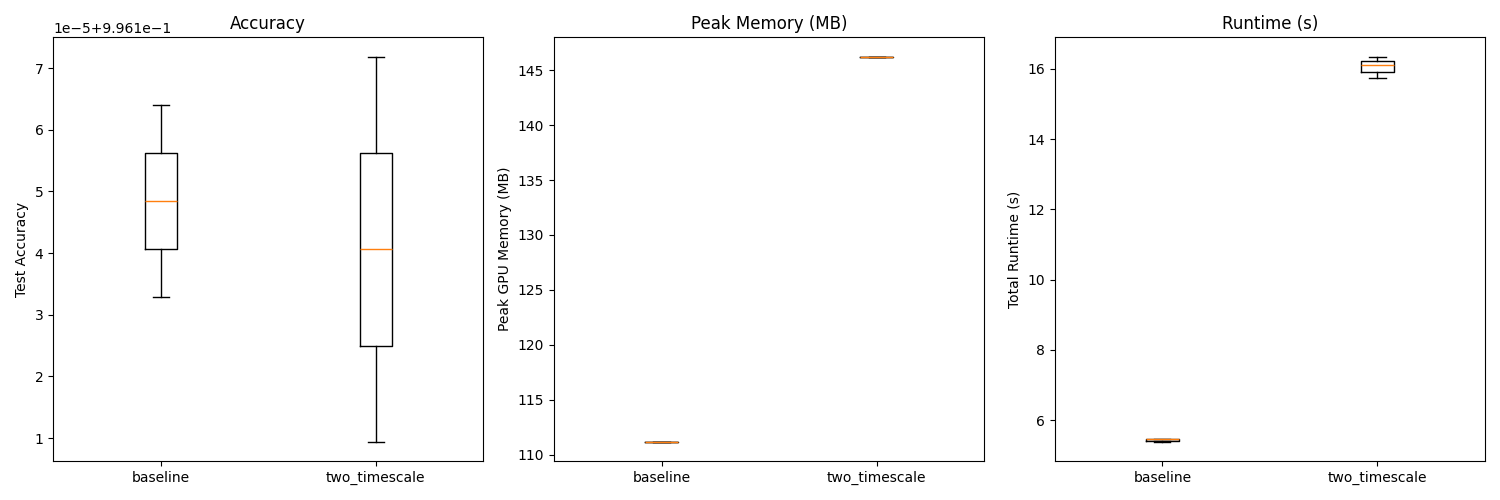

In [7]:

# Cell 3: Display the generated comparison plot
from IPython.display import Image
Image('outputs/experiment_results.png')